In [2]:
import pandas as pd
import numpy as np
from scipy.stats import kruskal, spearmanr
from scipy.stats.distributions import chi2
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import NMF
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split

# Load data
X0 = pd.read_excel('minmax01.xlsx').values
y = pd.read_csv('../idC_with_header.csv').values.flatten() - 1

# TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X0, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data split: Train {X_train.shape}, Test {X_test.shape}")

n_wavelengths = X_train.shape[1]
components_range0 = [10, 16, 20, 25, 32, 40, 50, 75, 100]

nmf_cache = {}

def fit_nmf_stable(X_train, X_test, n_comp, n_runs=10, n_seeds=None):
    """
    Fit NMF on training set only. Evaluate reconstruction error on both train & test.
    Returns U, V matrices, recon errors, and train-test metrics.
    """
    if n_seeds is None:
        n_seeds = np.arange(42, 42 + n_runs)
    
    U_train_list = []
    U_test_list = []
    V_list = []
    models = []
    recon_errors_train = []
    recon_errors_test = []
    
    for seed in n_seeds:
        nmf = NMF(n_components=n_comp, init='random', random_state=seed, max_iter=1000)
        
        # Fit on train
        U_train = nmf.fit_transform(X_train)
        U_train_list.append(U_train)
        V_list.append(nmf.components_)
        models.append(nmf)
        
        # Training reconstruction error
        recon_err_train = nmf.reconstruction_err_
        recon_errors_train.append(recon_err_train)
        
        # Test reconstruction error (transform test set, then evaluate)
        U_test = nmf.transform(X_test)
        X_test_recon = U_test @ nmf.components_
        recon_err_test = np.linalg.norm(X_test - X_test_recon, 'fro')
        recon_errors_test.append(recon_err_test)
        
        U_test_list.append(U_test)
    
    return {
        'U_train_list': U_train_list,
        'U_test_list': U_test_list,
        'V_list': V_list,
        'models': models,
        'recon_errors_train': recon_errors_train,
        'recon_errors_test': recon_errors_test,
        'recon_error_train_mean': np.mean(recon_errors_train),
        'recon_error_train_std': np.std(recon_errors_train),
        'recon_error_test_mean': np.mean(recon_errors_test),
        'recon_error_test_std': np.std(recon_errors_test),
        'generalization_gap': np.mean(recon_errors_test) - np.mean(recon_errors_train)
    }

print("="*70)
print("PHASE 1: FIT NMF ON TRAIN SET, EVALUATE ON TEST SET")
print("="*70)

for n_comp in [10,32,40]:
    print(f"\nFitting NMF with n_components={n_comp} across 10 seeds (train only)...")
    nmf_cache[n_comp] = fit_nmf_stable(X_train, X_test, n_comp, n_runs=10)
    
    cache_entry = nmf_cache[n_comp]
    print(f"  Train Recon Error: {cache_entry['recon_error_train_mean']:.4f} ± {cache_entry['recon_error_train_std']:.4f}")
    print(f"  Test Recon Error:  {cache_entry['recon_error_test_mean']:.4f} ± {cache_entry['recon_error_test_std']:.4f}")
    print(f"  Generalization Gap: {cache_entry['generalization_gap']:.4f}")

Data split: Train (354, 900), Test (89, 900)
PHASE 1: FIT NMF ON TRAIN SET, EVALUATE ON TEST SET

Fitting NMF with n_components=10 across 10 seeds (train only)...
  Train Recon Error: 48.0822 ± 0.0221
  Test Recon Error:  27.5361 ± 0.0505
  Generalization Gap: -20.5461

Fitting NMF with n_components=32 across 10 seeds (train only)...
  Train Recon Error: 34.8253 ± 0.0355
  Test Recon Error:  22.5870 ± 0.0664
  Generalization Gap: -12.2382

Fitting NMF with n_components=40 across 10 seeds (train only)...
  Train Recon Error: 31.9755 ± 0.0351
  Test Recon Error:  21.6757 ± 0.0796
  Generalization Gap: -10.2997


In [3]:
def analyze_factor_scores(U_list, y_train, factor_idx):
    """
    Kruskal-Wallis test on factor scores across classes.
    U_list: list of (n_samples, n_components) matrices from multiple NMF runs
    y_train: class labels (n_samples,)
    factor_idx: which factor to analyze
    """
    factor_scores = [U_list[i][:, factor_idx] for i in range(len(U_list))]
    factor_scores_mean = np.mean(factor_scores, axis=0)
    
    groups = [factor_scores_mean[y_train == c] for c in np.unique(y_train)]
    
    h_stat, p_value = kruskal(*groups)
    
    # Effect size (eta-squared approximation from H statistic)
    n = len(factor_scores_mean)
    k = len(groups)
    eta_sq = (h_stat - k + 1) / (n - k)
    eta_sq = max(0, eta_sq)  # Bound at 0
    
    # Spearman correlation with class (encode as ordinal)
    rho, rho_p = spearmanr(factor_scores_mean, y_train)
    
    return {
        'factor': factor_idx,
        'H_stat': h_stat,
        'p_value': p_value,
        'eta_sq': eta_sq,
        'spearman_rho': rho,
        'spearman_p': rho_p,
        'mean_score': np.mean(factor_scores_mean),
        'std_score': np.std(factor_scores_mean)
    }

def analyze_nmf_component(n_comp, U_train_list, V_list, y_train, X_train):
    """
    Full statistical analysis for one NMF component set.
    Uses training data only.
    """
    n_factors = U_train_list[0].shape[1]
    results = []
    
    for factor_idx in range(n_factors):
        factor_stats = analyze_factor_scores(U_train_list, y_train, factor_idx)
        results.append(factor_stats)
    
    df = pd.DataFrame(results)
    
    # BH correction
    reject, qvals, _, _ = multipletests(df['p_value'], method='fdr_bh')
    df['q_value_BH'] = qvals
    df['significant_BH'] = reject
    
    return df

print("\n" + "="*70)
print("PHASE 2: STATISTICAL TESTS ON FACTOR SCORES (U)")
print("="*70)

stats_by_component = {}

for n_comp in [10,32,40]:
    print(f"\nAnalyzing n_components={n_comp}...")
    U_train_list = nmf_cache[n_comp]['U_train_list']
    V_list = nmf_cache[n_comp]['V_list']
    
    df_stats = analyze_nmf_component(n_comp, U_train_list, V_list, y_train, X_train)
    stats_by_component[n_comp] = df_stats

    df_stats.to_csv(f"nmf_stats_{n_comp}.csv", index=False)

    print("\n" + "="*80)
    print(f"n_components = {n_comp}")
    print("="*80)
    
    df = stats_by_component[n_comp]
    print(df.to_string(index=False))
    
    # Show significant factors
    '''sig_factors = df_stats[df_stats['significant_BH']]
    print(f"  Significant factors (BH-adj): {len(sig_factors)}/{n_comp}")
    if len(sig_factors) > 0:
        print(sig_factors[['factor', 'H_stat', 'q_value_BH', 'eta_sq', 'spearman_rho']].to_string(index=False))'''


PHASE 2: STATISTICAL TESTS ON FACTOR SCORES (U)

Analyzing n_components=10...

n_components = 10
 factor     H_stat      p_value   eta_sq  spearman_rho   spearman_p  mean_score  std_score   q_value_BH  significant_BH
      0 252.269268 2.162694e-46 0.703733      0.235410 7.583454e-06    0.473567   0.188225 1.081347e-45            True
      1 217.145726 4.045843e-39 0.600429     -0.267636 3.200066e-07    0.270573   0.121181 1.011461e-38            True
      2 207.481597 3.961525e-37 0.572005      0.195053 2.221059e-04    0.296517   0.081035 7.923050e-37            True
      3 251.222865 3.567557e-46 0.700655     -0.091372 8.603937e-02    0.238684   0.073475 1.189186e-45            True
      4  71.898164 3.583417e-10 0.173230     -0.114090 3.187249e-02    0.221783   0.048156 3.981575e-10            True
      5 146.042373 1.289889e-24 0.391301     -0.045231 3.961903e-01    0.206246   0.070862 2.149815e-24            True
      6 306.856065 8.831923e-58 0.864283     -0.437450 5.58550

In [17]:
def analyze_basis_matrix(V_list, X0, top_n=5):
    """
    V: basis matrix (n_components, n_wavelengths)
    - Concentration: how peaked is each factor across wavelengths?
    - Top wavelengths: which wavelengths have highest weights?
    """
    wavenumbers = np.linspace(500, 4000, X0.shape[1])

    V_mean = np.mean(V_list, axis=0)  # Average across seeds
    n_components = V_mean.shape[0]
    #n_wavelengths = V_mean.shape[1]
    
    factor_info = []
    
    for factor_idx in range(n_components):
        basis = V_mean[factor_idx, :]
        
        # Concentration: Gini coefficient or entropy
        # Gini = 1 - (2 * sum(rank * weight)) / (n * sum(weight))
        sorted_basis = np.sort(basis)
        n = len(sorted_basis)
        gini = (2 * np.sum(np.arange(1, n+1) * sorted_basis)) / (n * np.sum(sorted_basis)) - (n + 1) / n
        
        # Top wavelengths
        top_indices = np.argsort(basis)[-top_n:][::-1]
        #top_wavelengths = wavenumbers[top_indices]
        top_wavelengths = np.round(wavenumbers[top_indices]).astype(int)
        top_weights = basis[top_indices]
        
        # Total mass in top N wavelengths
        top_mass_fraction = np.sum(top_weights) / np.sum(basis)

        dominant_wn = wavenumbers[top_indices[0]]
        if   900  <= dominant_wn < 1200: interp = "C-O / C-C stretch (sugars, polysaccharides)"
        elif 1200 <= dominant_wn < 1400: interp = "C-H bending / carboxylate stretch"
        elif 1400 <= dominant_wn < 1600: interp = "C=C / COO⁻ stretch (organic acids)"
        elif 1600 <= dominant_wn < 1700: interp = "Amide I / C=O stretch (proteins)"
        elif 1700 <= dominant_wn < 1800: interp = "C=O ester stretch (lipids, esters)"
        elif 2800 <= dominant_wn < 3000: interp = "C-H stretch (lipids, waxes)"
        elif 3000 <= dominant_wn <= 3600: interp = "O-H stretch (water, alcohols)"
        else:                             interp = "Mixed / overlapping bands"
        
        factor_info.append({
            'factor': factor_idx,
            'gini_concentration': gini,
            'top_mass_fraction': top_mass_fraction,
            'top_indices': top_indices,
            'top_wavelengths': top_wavelengths,
            'top_weights': top_weights,
            'max_weight': np.max(basis),
            'mean_weight': np.mean(basis),
            'interp': interp
        })

    df_basis = pd.DataFrame(rows)
    df_basis.to_csv(f"nmf_basis_interpreted_{n_comp}.csv", index=False)
    
    return factor_info

print("\n" + "="*70)
print("PHASE 3: BASIS MATRIX (V) - WAVELENGTH CONTRIBUTIONS")
print("="*70)

basis_by_component = {}

for n_comp in [10,32,40]:
    print(f"\nAnalyzing basis matrix for n_components={n_comp}...")
    V_list = nmf_cache[n_comp]['V_list']
    
    basis_info = analyze_basis_matrix(V_list, X0, top_n=5)
    basis_by_component[n_comp] = basis_info

    df_basis = pd.DataFrame(basis_info)
    df_basis.to_csv(f"NMF_basis_interpreted_{n_comp}.csv", index=False)
    
    '''for info in basis_info[:3]:  # Show first 3 factors
        print(f"  Factor {info['factor']}:")
        print(f"    Gini (concentration): {info['gini_concentration']:.3f}")
        print(f"    Top 5 wavelengths mass: {info['top_mass_fraction']:.2%}")
        print(f"    Top wavelengths: {info['top_wavelengths']}")
        print(f"    Top weights: {info['top_weights']}")'''

    for info in basis_by_component[n_comp]:
        
        print("\n----------------------------------")
        print(f"Factor {info['factor']}")
        print("----------------------------------")
        
        print("Gini:", info['gini_concentration'])
        print("Top mass fraction:", info['top_mass_fraction'])
        
        print("\nIndex | Wavelength | Weight")
        for idx, wl, w, inter in zip(info['top_indices'], info['top_wavelengths'], info['top_weights'], info['interp']):
            print(f"  {idx} | {wl:.2f} | {w:.2f} | {inter}")


PHASE 3: BASIS MATRIX (V) - WAVELENGTH CONTRIBUTIONS

Analyzing basis matrix for n_components=10...

----------------------------------
Factor 0
----------------------------------
Gini: 0.3035351055839617
Top mass fraction: 0.013695600025716

Index | Wavelength | Weight
  715 | 3284.00 | 0.42 | O
  713 | 3276.00 | 0.42 | -
  714 | 3280.00 | 0.42 | H
  758 | 3451.00 | 0.41 |  
  670 | 3108.00 | 0.41 | s

----------------------------------
Factor 1
----------------------------------
Gini: 0.20119378858010717
Top mass fraction: 0.01161533018156448

Index | Wavelength | Weight
  620 | 2914.00 | 0.29 | C
  621 | 2918.00 | 0.28 | -
  622 | 2922.00 | 0.28 | H
  619 | 2910.00 | 0.28 |  
  623 | 2925.00 | 0.27 | s

----------------------------------
Factor 2
----------------------------------
Gini: 0.18508206798441518
Top mass fraction: 0.010700300247001585

Index | Wavelength | Weight
  287 | 1617.00 | 0.41 | A
  286 | 1613.00 | 0.39 | m
  305 | 1687.00 | 0.37 | i
  285 | 1610.00 | 0.37 | d
 

In [7]:
def bootstrap_stability(X, y, n_comp, n_bootstrap=50, seed=42):
    np.random.seed(seed)

    n_samples = X.shape[0]

    # store U matrices for each bootstrap
    U_bootstrap_list = []

    recon_errors = []

    for b in range(n_bootstrap):
        idx_boot = np.random.choice(n_samples, size=n_samples, replace=True)
        X_boot = X[idx_boot, :]

        nmf = NMF(n_components=n_comp, init='nndsvd', random_state=b, max_iter=1000)
        U = nmf.fit_transform(X_boot)

        recon_errors.append(nmf.reconstruction_err_)

        # reorder back to original space (approx alignment)
        U_bootstrap_list.append(U[np.argsort(idx_boot), :])

    U_bootstrap_list = np.array(U_bootstrap_list)  # shape: (B, n_samples, n_comp)

    # -------- FACTOR-WISE STABILITY --------
    factor_stability = []

    for k in range(n_comp):
        factor_values = U_bootstrap_list[:, :, k]  # all bootstraps for factor k

        # variability across bootstraps
        factor_std = np.std(factor_values)

        # coefficient of variation (normalized stability)
        factor_mean = np.mean(factor_values)
        factor_cv = factor_std / (factor_mean + 1e-8)

        factor_stability.append({
            'factor': k,
            'std': factor_std,
            'cv': factor_cv,
            'mean': factor_mean
        })

    return {
        'recon_error_mean': np.mean(recon_errors),
        'recon_error_std': np.std(recon_errors),
        'recon_error_cv': np.std(recon_errors) / np.mean(recon_errors),
        'factor_stability': factor_stability
    }

print("\n" + "="*70)
print("PHASE 4: STABILITY ACROSS BOOTSTRAP & CROSS-VALIDATION")
print("="*70)

stability_metrics = {}

for n_comp in [10,32,40]:
    boot = bootstrap_stability(X0, y, n_comp)

    df_factors = pd.DataFrame(boot['factor_stability'])
    df_factors.to_csv(f"nmf_stability_factors_{n_comp}.csv", index=False)
    
    print("\n" + "="*80)
    print(f"n_components = {n_comp}")
    print("="*80)

    print(f"Recon CV: {boot['recon_error_cv']:.4f}")

    print("\nFactor-wise stability:")
    for f in boot['factor_stability']:
        print(f"Factor {f['factor']:2d} | CV={f['cv']:.4f} | STD={f['std']:.4f}")


PHASE 4: STABILITY ACROSS BOOTSTRAP & CROSS-VALIDATION

n_components = 10
Recon CV: 0.0169

Factor-wise stability:
Factor  0 | CV=0.5885 | STD=0.2330
Factor  1 | CV=0.8580 | STD=0.2286
Factor  2 | CV=0.9628 | STD=0.2578
Factor  3 | CV=0.8614 | STD=0.2493
Factor  4 | CV=1.0633 | STD=0.4055
Factor  5 | CV=1.1281 | STD=0.3190
Factor  6 | CV=1.1022 | STD=0.3066
Factor  7 | CV=1.1123 | STD=0.2804
Factor  8 | CV=1.0561 | STD=0.3339
Factor  9 | CV=1.1894 | STD=0.4334

n_components = 32
Recon CV: 0.0148

Factor-wise stability:
Factor  0 | CV=0.8801 | STD=0.1617
Factor  1 | CV=1.2368 | STD=0.1763
Factor  2 | CV=1.3577 | STD=0.2038
Factor  3 | CV=1.1429 | STD=0.1893
Factor  4 | CV=1.7527 | STD=0.2886
Factor  5 | CV=1.7476 | STD=0.2655
Factor  6 | CV=1.4851 | STD=0.2410
Factor  7 | CV=1.6563 | STD=0.2377
Factor  8 | CV=1.7204 | STD=0.2703
Factor  9 | CV=1.8863 | STD=0.3571
Factor 10 | CV=1.4286 | STD=0.2581
Factor 11 | CV=1.6555 | STD=0.2855
Factor 12 | CV=1.6849 | STD=0.2557
Factor 13 | CV=1.63

In [ ]:
print("\n" + "="*70)
print("FINAL SUMMARY: STATISTICAL + STABILITY METRICS")
print("="*70)

summary_rows = []

for n_comp in components_range0:
    df_stats = stats_by_component[n_comp]
    stab = stability_metrics[n_comp]
    
    # Count significant factors
    n_sig = df_stats['significant_BH'].sum()
    mean_eta_sq = df_stats['eta_sq'].mean()
    mean_rho = df_stats['spearman_rho'].abs().mean()
    
    summary_rows.append({
        'n_components': n_comp,
        'recon_error_train': nmf_cache[n_comp]['recon_error_train_mean'],
        'recon_error_test': nmf_cache[n_comp]['recon_error_test_mean'],
        'recon_error_train_stability': nmf_cache[n_comp]['recon_error_train_std'],
        'recon_error_test_stability': nmf_cache[n_comp]['recon_error_test_std'],
        'generalization_gap': nmf_cache[n_comp]['generalization_gap'],
        'n_significant_factors': n_sig,
        'mean_eta_sq': mean_eta_sq,
        'mean_|rho|': mean_rho,
        'bootstrap_cv': stab['bootstrap']['recon_error_cv'],
        'cv_generalization_gap': stab['cv']['generalization_gap'],
    })

df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))

#df_summary.to_csv('nmf_stability_summary.csv', index=False)

# Recommended range: low recon error + high stability + interpretable factors
print("\n✓ Recommended components based on:")
print("  - Low test reconstruction error (honest evaluation)")
print("  - Small generalization gap (not overfitting)")
print("  - High statistical significance (η², |ρ|)")
print("  - Low instability (CV, bootstrap)")
print(f"\n  Best candidates: {df_summary[df_summary['bootstrap_cv'] < 0.2]['n_components'].values}")


FINAL SUMMARY: STATISTICAL + STABILITY METRICS
 n_components  recon_error_train  recon_error_test  recon_error_train_stability  recon_error_test_stability  generalization_gap  n_significant_factors  mean_eta_sq  mean_|rho|  bootstrap_cv  cv_generalization_gap
           10          48.082167         27.536105                     0.022146                    0.050505          -20.546062                     10     0.474185    0.160450      0.017016             -22.688406
           16          42.980145         25.615194                     0.043543                    0.164680          -17.364951                     16     0.351921    0.155362      0.015233             -19.077516
           20          40.459580         24.584166                     0.036010                    0.113728          -15.875415                     20     0.386677    0.249118      0.015068             -17.452851
           25          37.845037         23.601551                     0.046239                    0

Testing NMF with different n_components for RF
------------------------------------------------------------
n_components= 10 | CV F1: 0.8064 ± 0.0442 | Test Acc: 84.27% | Sig Factors: 10/10
n_components= 16 | CV F1: 0.7898 ± 0.0154 | Test Acc: 84.27% | Sig Factors: 16/16
n_components= 20 | CV F1: 0.7848 ± 0.0434 | Test Acc: 80.90% | Sig Factors: 20/20
n_components= 25 | CV F1: 0.8097 ± 0.0336 | Test Acc: 82.02% | Sig Factors: 25/25
n_components= 32 | CV F1: 0.8088 ± 0.0277 | Test Acc: 85.39% | Sig Factors: 32/32
n_components= 40 | CV F1: 0.7987 ± 0.0655 | Test Acc: 82.02% | Sig Factors: 39/40
n_components= 50 | CV F1: 0.7742 ± 0.0541 | Test Acc: 85.39% | Sig Factors: 50/50
n_components= 75 | CV F1: 0.8067 ± 0.0389 | Test Acc: 82.02% | Sig Factors: 74/75
n_components=100 | CV F1: 0.7623 ± 0.0475 | Test Acc: 85.39% | Sig Factors: 98/100
✓ Optimal for RF: 25

Testing NMF with different n_components for SVM
------------------------------------------------------------
n_components= 10 | CV 

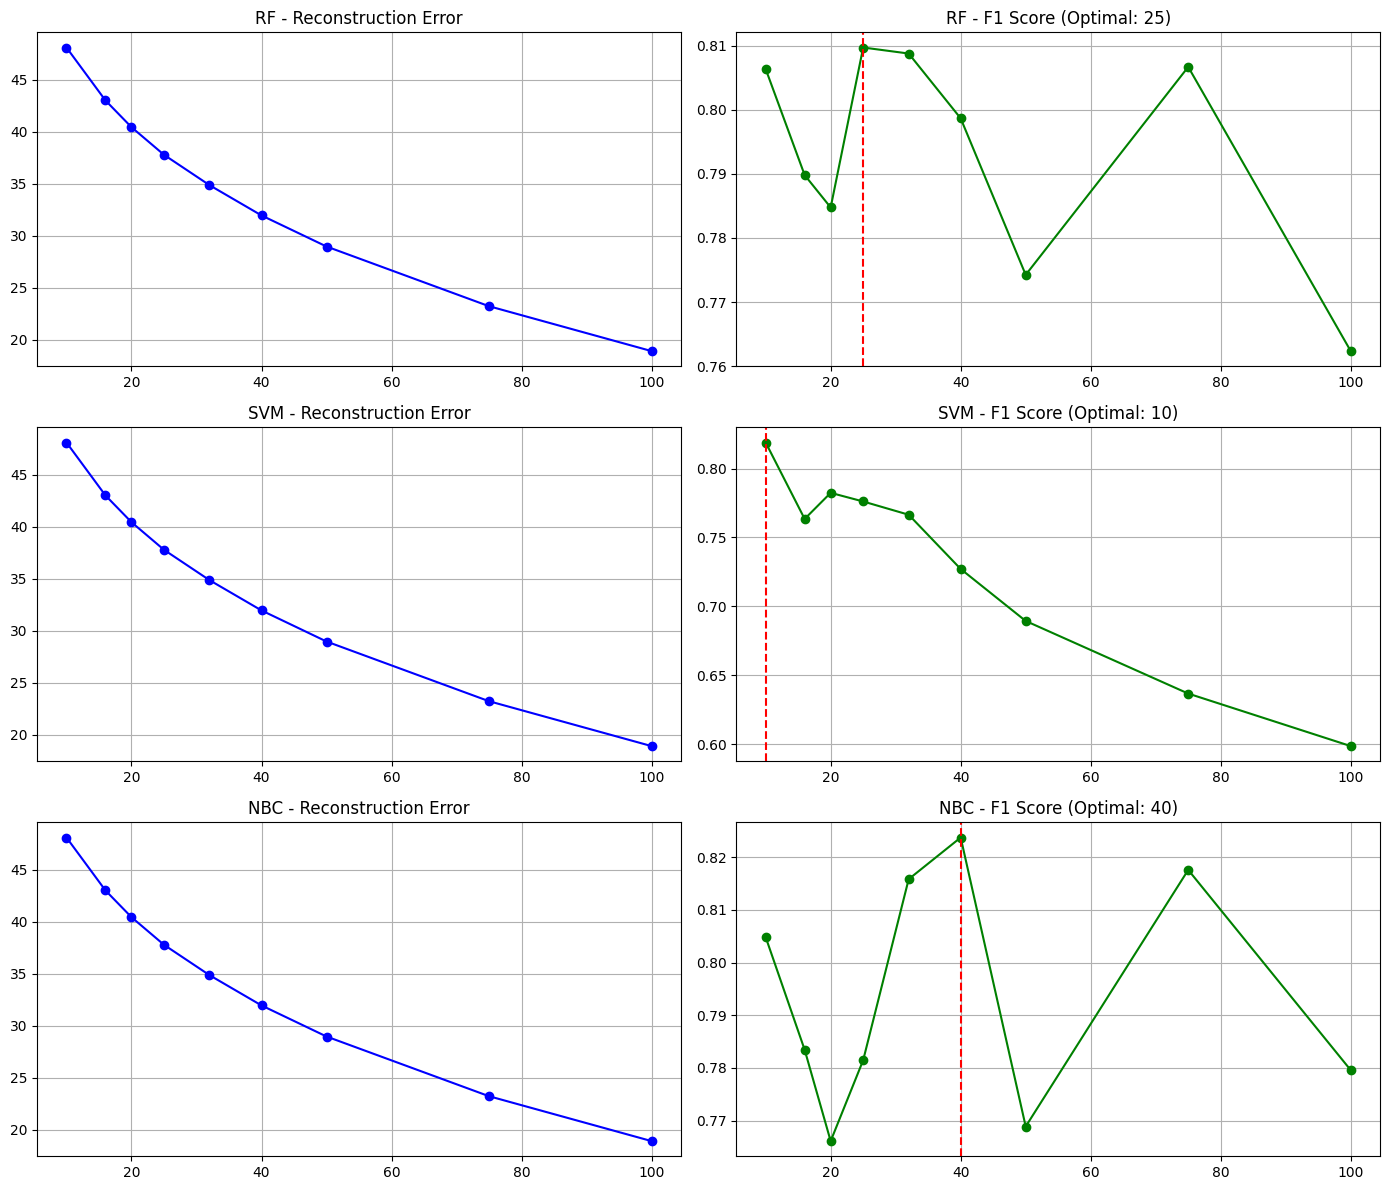


SUMMARY
RF Best: 25
SVM Best: 10
NBC Best: 40


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kruskal, spearmanr
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import NMF
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# Load data
X0 = pd.read_excel('minmax01.xlsx').values
y = pd.read_csv('../idC_with_header.csv').values.flatten() - 1

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X0, y, test_size=0.2, random_state=42, stratify=y
)

components_range0 = [10, 16, 20, 25, 32, 40, 50, 75, 100]

# Results containers
def init_results():
    return {'n_components': [], 'test_acc_pct': [], 'test_f1': [], 'cv_f1': [],
            'cv_f1_std': [], 'n_sig_factors': [], 'mean_eta_sq': [], 'mean_rho': [],
            'bootstrap_cv': [], 'mean_gini': [], 'recon_error': []}

rf_results0 = init_results()
svm_results0 = init_results()
nbc_results0 = init_results()

# ===================== HELPERS =====================

def compute_stats(U_list, y_train, n_comp):
    results = []
    for factor_idx in range(n_comp):
        factor_scores = [U_list[i][:, factor_idx] for i in range(len(U_list))]
        factor_scores_mean = np.mean(factor_scores, axis=0)
        groups = [factor_scores_mean[y_train == c] for c in np.unique(y_train)]
        h_stat, p_value = kruskal(*groups)

        n = len(factor_scores_mean)
        k = len(groups)
        eta_sq = (h_stat - k + 1) / (n - k)
        eta_sq = max(0, eta_sq)

        rho, _ = spearmanr(factor_scores_mean, y_train)
        results.append({'p_value': p_value, 'eta_sq': eta_sq, 'rho': rho})

    df = pd.DataFrame(results)
    reject, qvals, _, _ = multipletests(df['p_value'], method='fdr_bh')
    df['significant'] = reject

    return df['significant'].sum(), df['eta_sq'].mean(), np.abs(df['rho']).mean()

def compute_bootstrap_cv(X_train, n_comp, n_bootstrap=10):
    errors = []
    for seed in range(42, 42 + n_bootstrap):
        idx = np.random.choice(len(X_train), size=len(X_train), replace=True)
        X_boot = X_train[idx, :]
        nmf = NMF(n_components=n_comp, init='nndsvd', random_state=seed, max_iter=1000)
        nmf.fit_transform(X_boot)
        errors.append(nmf.reconstruction_err_)
    return np.std(errors) / np.mean(errors) if np.mean(errors) > 0 else 0

def compute_gini(V_list):
    V_mean = np.mean(V_list, axis=0)
    gini_scores = []
    for factor_idx in range(V_mean.shape[0]):
        basis = V_mean[factor_idx, :]
        sorted_basis = np.sort(basis)
        n = len(sorted_basis)
        gini = (2 * np.sum(np.arange(1, n+1) * sorted_basis)) / (n * np.sum(basis)) - (n + 1) / n
        gini_scores.append(gini)
    return np.mean(gini_scores)

# ===================== MAIN LOOP FUNCTION =====================

def run_experiment(results_dict, classifier, clf_name):
    print(f"Testing NMF with different n_components for {clf_name}")
    print("-" * 60)

    for n_comp in components_range0:

        # NMF (single, stable)
        nmf = NMF(n_components=n_comp, init='nndsvd', random_state=42, max_iter=1000)
        U_train = nmf.fit_transform(X_train)
        U_test = nmf.transform(X_test)
        V = nmf.components_

        # Train classifier
        clf = classifier
        clf.fit(U_train, y_train)

        # Test
        y_pred = clf.predict(U_test)
        test_acc = accuracy_score(y_test, y_pred)
        test_f1 = f1_score(y_test, y_pred, average='weighted')

        # Proper CV (no leakage)
        pipeline = Pipeline([
            ('nmf', NMF(n_components=n_comp, init='nndsvd', random_state=42, max_iter=1000)),
            ('clf', classifier)
        ])

        cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1_weighted')

        # Stats
        n_sig, mean_eta, mean_rho = compute_stats([U_train], y_train, n_comp)
        bootstrap_cv = compute_bootstrap_cv(X_train, n_comp)
        mean_gini = compute_gini([V])

        # Store
        results_dict['n_components'].append(n_comp)
        results_dict['test_acc_pct'].append(test_acc * 100)
        results_dict['test_f1'].append(test_f1)
        results_dict['cv_f1'].append(cv_scores.mean())
        results_dict['cv_f1_std'].append(cv_scores.std())
        results_dict['n_sig_factors'].append(n_sig)
        results_dict['mean_eta_sq'].append(mean_eta)
        results_dict['mean_rho'].append(mean_rho)
        results_dict['bootstrap_cv'].append(bootstrap_cv)
        results_dict['mean_gini'].append(mean_gini)
        results_dict['recon_error'].append(nmf.reconstruction_err_)

        print(f"n_components={n_comp:3d} | CV F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | Test Acc: {test_acc*100:.2f}% | Sig Factors: {n_sig}/{n_comp}")

    best_n = results_dict['n_components'][np.argmax(results_dict['cv_f1'])]
    print(f"✓ Optimal for {clf_name}: {best_n}\n")
    return best_n

# ===================== RUN =====================

best_rf0 = run_experiment(rf_results0, RandomForestClassifier(random_state=42), "RF")
best_svm0 = run_experiment(svm_results0, SVC(random_state=42), "SVM")
best_nbc0 = run_experiment(nbc_results0, GaussianNB(), "NBC")

# ===================== PLOTTING =====================

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

def plot_results(ax_row, results, title, best_n):
    ax_row[0].plot(results['n_components'], results['recon_error'], 'bo-')
    ax_row[0].set_title(f'{title} - Reconstruction Error')
    ax_row[0].grid()

    ax_row[1].plot(results['n_components'], results['cv_f1'], 'go-')
    ax_row[1].axvline(best_n, color='r', linestyle='--')
    ax_row[1].set_title(f'{title} - F1 Score (Optimal: {best_n})')
    ax_row[1].grid()

plot_results(axes[0], rf_results0, "RF", best_rf0)
plot_results(axes[1], svm_results0, "SVM", best_svm0)
plot_results(axes[2], nbc_results0, "NBC", best_nbc0)

plt.tight_layout()
plt.show()

# ===================== SUMMARY =====================

print("\nSUMMARY")
print(f"RF Best: {best_rf0}")
print(f"SVM Best: {best_svm0}")
print(f"NBC Best: {best_nbc0}")

In [6]:
rf_df = pd.DataFrame(rf_results0)
print(rf_df)

   n_components  test_acc_pct   test_f1     cv_f1  cv_f1_std  n_sig_factors  \
0            10     84.269663  0.841840  0.806361   0.044183             10   
1            16     84.269663  0.835692  0.789800   0.015365             16   
2            20     80.898876  0.803824  0.784753   0.043396             20   
3            25     82.022472  0.812738  0.809714   0.033592             25   
4            32     85.393258  0.848264  0.808774   0.027715             32   
5            40     82.022472  0.808609  0.798658   0.065517             39   
6            50     85.393258  0.847679  0.774239   0.054058             50   
7            75     82.022472  0.808095  0.806687   0.038900             74   
8           100     85.393258  0.844204  0.762339   0.047475             98   

   mean_eta_sq  mean_rho  bootstrap_cv  mean_gini  recon_error  
0     0.415582  0.210143      0.015897   0.405888    48.084170  
1     0.337158  0.192922      0.016993   0.459762    42.994933  
2     0.316436

In [7]:
rf_df = pd.DataFrame(rf_results0)
svm_df = pd.DataFrame(svm_results0)
nbc_df = pd.DataFrame(nbc_results0)

print("\n=== RANDOM FOREST ===")
print(rf_df.to_string(index=False))

print("\n=== SVM ===")
print(svm_df.to_string(index=False))

print("\n=== NAIVE BAYES ===")
print(nbc_df.to_string(index=False))


=== RANDOM FOREST ===
 n_components  test_acc_pct  test_f1    cv_f1  cv_f1_std  n_sig_factors  mean_eta_sq  mean_rho  bootstrap_cv  mean_gini  recon_error
           10     84.269663 0.841840 0.806361   0.044183             10     0.415582  0.210143      0.015897   0.405888    48.084170
           16     84.269663 0.835692 0.789800   0.015365             16     0.337158  0.192922      0.016993   0.459762    42.994933
           20     80.898876 0.803824 0.784753   0.043396             20     0.316436  0.194479      0.014707   0.498139    40.427490
           25     82.022472 0.812738 0.809714   0.033592             25     0.278236  0.179295      0.011640   0.517549    37.773872
           32     85.393258 0.848264 0.808774   0.027715             32     0.259934  0.152056      0.009113   0.557649    34.856242
           40     82.022472 0.808609 0.798658   0.065517             39     0.225341  0.134194      0.009480   0.569592    31.947118
           50     85.393258 0.847679 0.774239 